# Tasks:
* Remember: scale your data appropriately

* Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

* Decide your optimization metric.

* Write down your network architecture. You can start from a fully connected, multi-layer perceptron (and then explore)

* Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning.

* Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best. Do your best now to optimize the network architecture. Be creative!

* Report on the perfomance of the network on the test set; report other metrics that have not been optimized.

A few tips:
* In scikit-learn, remember that you can utilize all availables cores on your machine with n_jobs=-1. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
* If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
* On cross validation, for scikit learn we've seen how to use GridSearchCV already. For Tensorflow, there's a really cool tool called Tensorboard

# Galaxy vs QSO

In [7]:
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler



### Loading and inspection

In [8]:

def load_data(csv_path: Path):
    df = pd.read_csv(csv_path)
    df = df.dropna()

    # Build color features from magnitudes.
    df["u-g"] = df["u"] - df["g"]
    df["g-r"] = df["g"] - df["r"]
    df["r-i"] = df["r"] - df["i"]
    df["i-z"] = df["i"] - df["z"]

    feature_cols = ["u-g", "g-r", "r-i", "i-z"]
    X = df[feature_cols].to_numpy(dtype=float)
    y = (df["class"] == "QSO").astype(int).to_numpy()
    return X, y, feature_cols

In [9]:
csv = '..\solutions\galaxyquasar.csv'

In [10]:
X, y, feature_cols = load_data(csv)
print(f"Loaded {len(X)} objects with {X.shape[1]} features: {feature_cols}")

Loaded 50000 objects with 4 features: ['u-g', 'g-r', 'r-i', 'i-z']


In [11]:
len(y[y==0])/len(y), len(y[y==1])/len(y)

(0.85732, 0.14268)

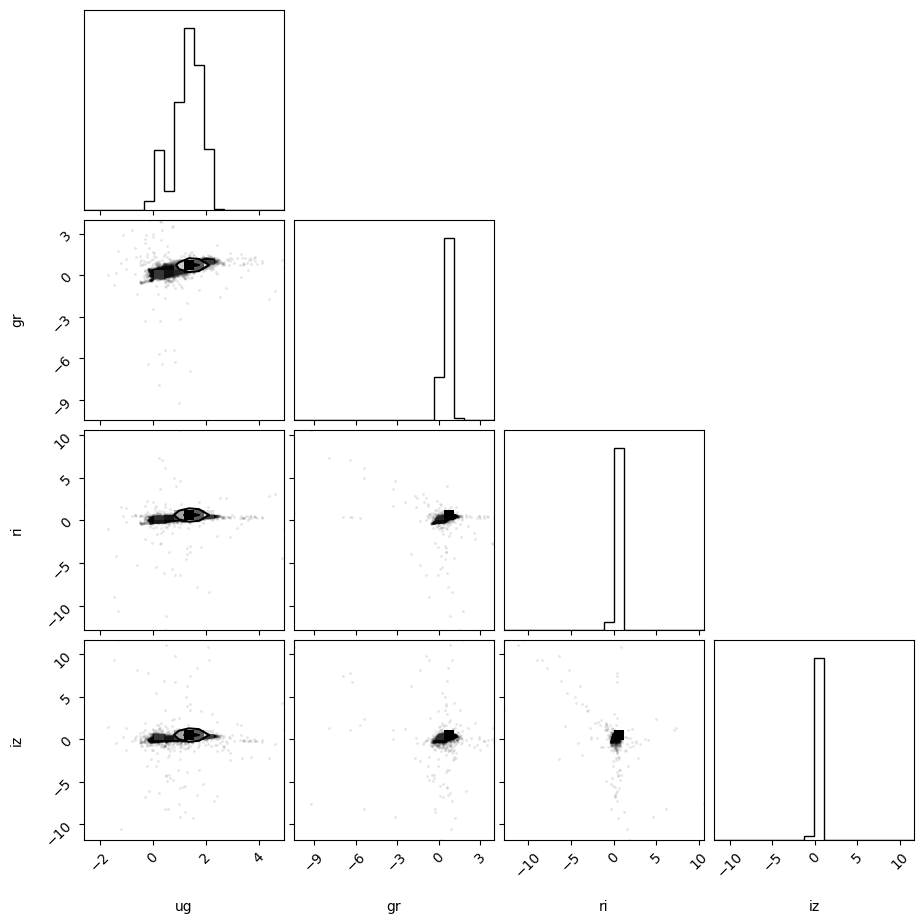

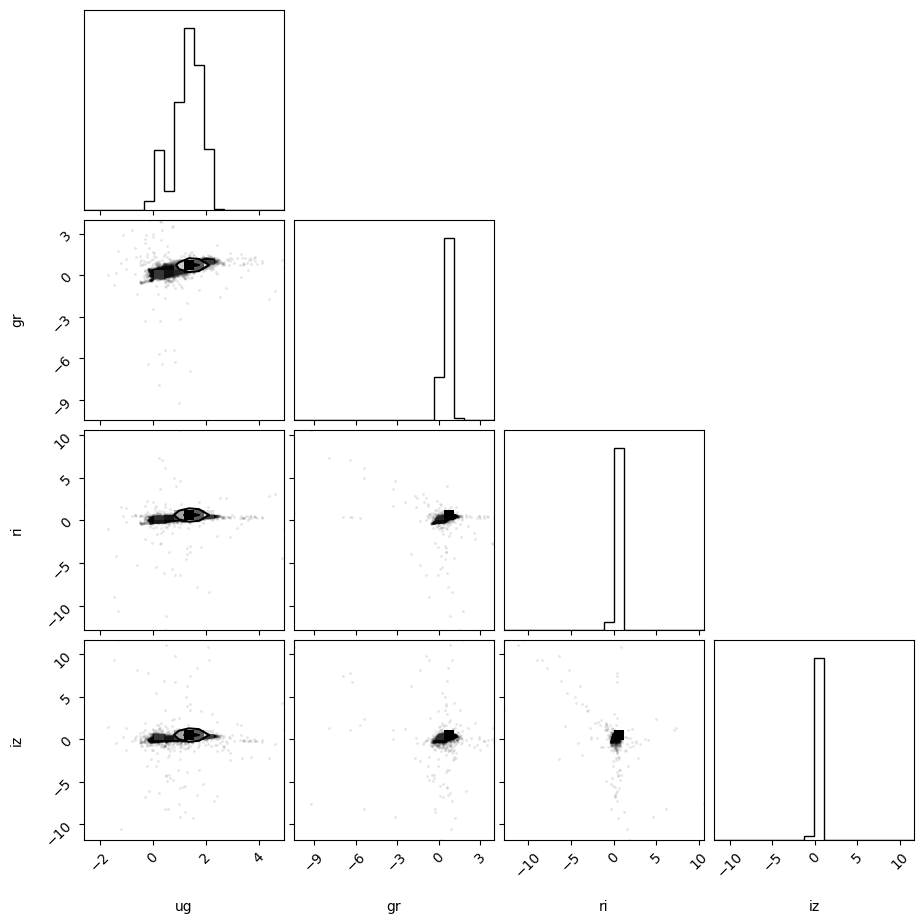

In [12]:
import corner

corner.corner(X, labels=['ug', 'gr', 'ri', 'iz'])

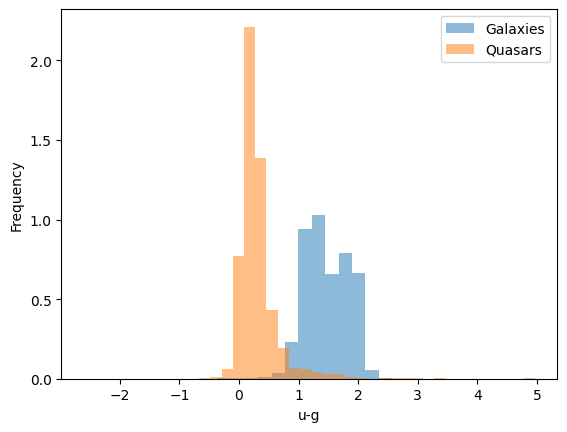

In [13]:
plt.hist(X[y == 0, 0], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 0], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('u-g')
plt.ylabel('Frequency')
plt.legend()
plt.show()


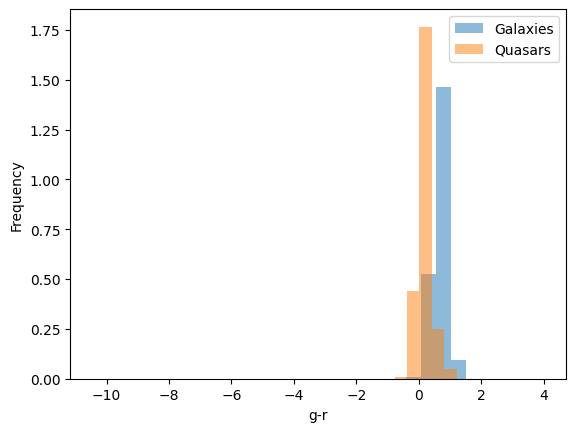

In [14]:
plt.hist(X[y == 0, 1], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 1], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('g-r')
plt.ylabel('Frequency')
plt.legend()
plt.show()

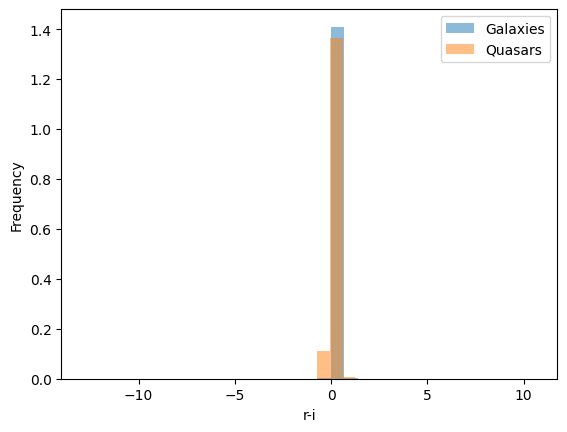

In [15]:
plt.hist(X[y == 0, 2], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 2], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('r-i')
plt.ylabel('Frequency')
plt.legend()
plt.show()

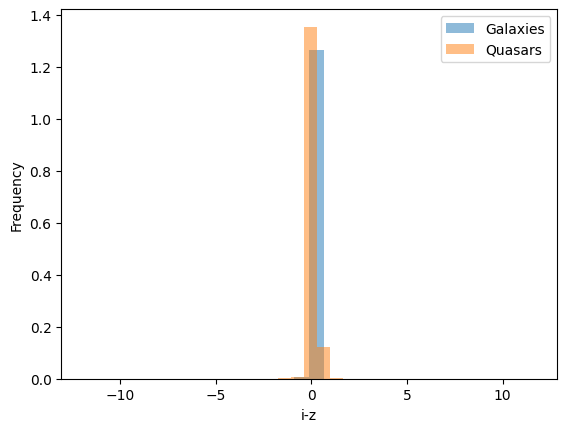

In [16]:
plt.hist(X[y == 0, 3], bins=30, alpha=0.5, label='Galaxies', density='True')
plt.hist(X[y == 1, 3], bins=30, alpha=0.5, label='Quasars', density='True')
plt.xlabel('i-z')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Common train / validation / test split (shared by all models)

In [17]:
# 1) Create common splits: train (60%), val (20%), test (20%)
from sklearn.model_selection import train_test_split

# Reserve a final test set (20%)
X_temp, X_common_test, y_temp, y_common_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Split remaining 80% into train (60% overall) and validation (20% overall)
X_common_train, X_common_val, y_common_train, y_common_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print('Shapes (train, val, test):', X_common_train.shape, X_common_val.shape, X_common_test.shape)

# Fit a single scaler on the training data and reuse it for all models (prevents leakage)
from sklearn.preprocessing import StandardScaler
scaler_common = StandardScaler()
X_common_train_s = scaler_common.fit_transform(X_common_train)
X_common_val_s = scaler_common.transform(X_common_val)
X_common_test_s = scaler_common.transform(X_common_test)

# Keep explicit names for later reuse
X_skl_train, X_skl_val, X_skl_test = X_common_train_s, X_common_val_s, X_common_test_s
y_skl_train, y_skl_val, y_skl_test = y_common_train, y_common_val, y_common_test

Shapes (train, val, test): (30000, 4) (10000, 4) (10000, 4)


### MLP

In [18]:
from sklearn.model_selection import GridSearchCV

def train_model_MLP(
    X_train_scaled,
    X_val_scaled,
    X_test_scaled,
    y_train,
    y_val,
    y_test,
    param_grid=None,
    max_iter=400,
    random_state=42,
):
    """Train and tune an MLP using train / validation / test splits.

    Hyperparameters are searched with cross validation on the training set.
    The validation set is used to confirm the selected hyperparameters.
    The test set is used only for the final evaluation.
    """
    if param_grid is None:
        param_grid = {
            # Try a few reasonable hidden layer configurations:
            # - smaller network for faster training
            # - deeper network for potentially more complex decision boundaries
            "hidden_layer_sizes": [(32, 16), (64, 32), (64, 32, 16)],
            # Regularization strength: smaller values allow more flexibility,
            # larger values penalize large weights and reduce overfitting.
            "alpha": [1e-4, 1e-3],
            # Learning rate for Adam optimizer: 1e-3 is a common default,
            # 1e-4 is a smaller rate that can stabilize training on harder cases.
            "learning_rate_init": [1e-3, 1e-4],
        }

    # Base MLP classifier with ReLU activation and Adam solver, because
    # this is a standard setting for tabular data and binary classification.
    base_clf = MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=max_iter,
        random_state=random_state,
    )

    # Use GridSearchCV to find the best hyperparameter combination on the training set.
    # cv=3 balances search cost and robustness in model selection.
    # scoring="roc_auc" focuses on ranking performance, which is important for
    # imbalanced or probability-sensitive binary classification.
    grid = GridSearchCV(
        base_clf,
        param_grid,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train_scaled, y_train)

    best_model = grid.best_estimator_
    print("Best CV params:", grid.best_params_)
    print("Best CV ROC AUC:", round(grid.best_score_, 4))

    def evaluate(name, model, X_eval, y_eval):
        y_pred = model.predict(X_eval)
        y_prob = model.predict_proba(X_eval)[:, 1]
        bal_acc = balanced_accuracy_score(y_eval, y_pred)
        roc_auc = roc_auc_score(y_eval, y_prob)
        avg_prec = average_precision_score(y_eval, y_prob)
        print(f"\n{name} balanced accuracy: {bal_acc:.4f}")
        print(f"{name} ROC AUC: {roc_auc:.4f}")
        print(f"{name} average precision: {avg_prec:.4f}")
        print(f"{name} confusion matrix:")
        print(confusion_matrix(y_eval, y_pred))
        print(f"\n{name} classification report:")
        print(classification_report(y_eval, y_pred, target_names=["GALAXY", "QSO"]))
        return bal_acc, roc_auc, avg_prec

    print("\nValidation set evaluation for selected model:")
    evaluate("Validation", best_model, X_val_scaled, y_val)

    # Combine train + validation to retrain the final model on all available
    # labeled data before testing, which usually improves final performance.
    X_combined = np.vstack((X_train_scaled, X_val_scaled))
    y_combined = np.concatenate((y_train, y_val))

    final_model = MLPClassifier(
        **grid.best_params_,
        activation="relu",
        solver="adam",
        max_iter=max_iter,
        random_state=random_state,
    )
    final_model.fit(X_combined, y_combined)

    test_acc, test_roc_auc, test_avg_prec = evaluate("Test", final_model, X_test_scaled, y_test)

    fpr, tpr, _ = roc_curve(y_test, final_model.predict_proba(X_test_scaled)[:, 1])
    
    return final_model, grid, fpr, tpr, test_acc, test_roc_auc, test_avg_prec

In [19]:
model_ML, grid_ML, fpr_ML, tpr_ML, test_acc_ML, test_roc_auc_ML, test_avg_prec_ML = train_model_MLP(X_skl_train, X_skl_test, X_skl_val, y_skl_train, y_skl_test, y_skl_val)

Best CV params: {'alpha': 0.001, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.001}
Best CV ROC AUC: 0.9935

Validation set evaluation for selected model:

Validation balanced accuracy: 0.9630
Validation ROC AUC: 0.9893
Validation average precision: 0.9720
Validation confusion matrix:
[[8509   64]
 [  95 1332]]

Validation classification report:
              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.95      0.93      0.94      1427

    accuracy                           0.98     10000
   macro avg       0.97      0.96      0.97     10000
weighted avg       0.98      0.98      0.98     10000


Test balanced accuracy: 0.9686
Test ROC AUC: 0.9928
Test average precision: 0.9735
Test confusion matrix:
[[8503   70]
 [  78 1349]]

Test classification report:
              precision    recall  f1-score   support

      GALAXY       0.99      0.99      0.99      8573
         QSO       0.95      0.95      0.95


Final test set evaluation:


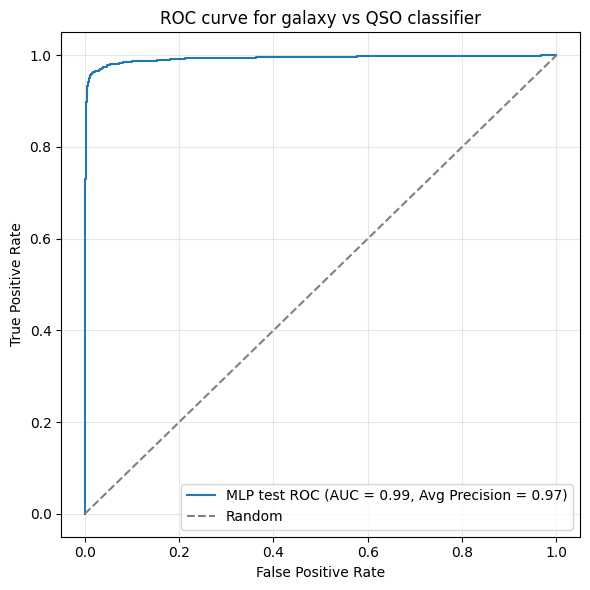

In [21]:

print("\nFinal test set evaluation:")
plt.figure(figsize=(6, 6))
plt.plot(fpr_ML, tpr_ML, label=f"MLP test ROC (AUC = {test_roc_auc_ML:.2f}, Avg Precision = {test_avg_prec_ML:.2f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve for galaxy vs QSO classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
                   

### Tensorflow

In [22]:
import tensorflow as tf

In [23]:
from tensorflow import keras
keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)

In [24]:
from sklearn.model_selection import KFold
import datetime

# Reshape scaled inputs for Keras Conv1D: (n_samples, time_steps, channels)
X_tf_train = X_skl_train[..., np.newaxis]
X_tf_val = X_skl_val[..., np.newaxis]
X_tf_test = X_skl_test[..., np.newaxis]

In [25]:
!pip install Tensorboard

In [18]:
model = keras.models.Sequential([
    keras.layers.InputLayer(shape=(4, 1)),
    keras.layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation="relu", padding="same"),
    keras.layers.Conv1D(128, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(256, 3, activation="relu", padding="same"),
    keras.layers.Conv1D(256, 3, activation="relu", padding="same"),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(units=128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation="softmax"),
])


In [26]:
from itertools import product
import datetime
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, classification_report


# Hyperparameter grid (search using validation set)
param_grid_TF = {
    "learning_rate": [1e-3, 1e-4],
    "dropout": [0.3, 0.5],
}
epochs = 10
best_val_auc_TF = -1.0

best_params_TF = None
best_model_TF = None

In [27]:

from itertools import product
import datetime


# ---------------------------------------------------------
# TensorFlow model definition
# ---------------------------------------------------------
def build_model(lr, dropout):
    model = keras.models.Sequential(
        [
            keras.layers.InputLayer(shape=(4, 1)),
            keras.layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
            keras.layers.MaxPooling1D(pool_size=2),
            keras.layers.Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"),
            keras.layers.GlobalAveragePooling1D(),
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Nadam(learning_rate=lr),
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )
    return model


# ---------------------------------------------------------
# Hyperparameter tuning on train/validation only
# ---------------------------------------------------------

best_val_auc_TF = -1.0
best_params_TF = None
best_model_TF = None

for lr, dropout in product(param_grid_TF["learning_rate"], param_grid_TF["dropout"]):
    run_name = f"lr_{lr}_do_{dropout}_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
    logdir = f"logs/tensorboard/hparams/{run_name}"

    tb = keras.callbacks.TensorBoard(log_dir=logdir)
    early_stopping_cb = keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
    )

    model_candidate = build_model(lr, dropout)
    model_candidate.fit(
        X_tf_train,
        y_skl_train,
        epochs=epochs,
        validation_data=(X_tf_val, y_skl_val),
        callbacks=[tb, early_stopping_cb],
        verbose=1,
    )

    y_val_prob = model_candidate.predict(X_tf_val, verbose=0).ravel()
    y_val_pred = (y_val_prob >= 0.5).astype(int)
    val_auc = roc_auc_score(y_skl_val, y_val_prob)
    val_avg_prec = average_precision_score(y_skl_val, y_val_prob)
    val_bal_acc = balanced_accuracy_score(y_skl_val, y_val_pred)

    print(f"Params lr={lr}, dropout={dropout} -> val_auc={val_auc:.4f}, val_pr_auc={val_avg_prec:.4f}, val_bal_acc={val_bal_acc:.4f}")
    if val_auc > best_val_auc_TF:
        best_val_auc_TF = val_auc
        best_params_TF = {"learning_rate": lr, "dropout": dropout}
        best_model_TF = model_candidate

print("\nBest TensorFlow hyperparameters (validation AUC):", best_params_TF)
print("Best TensorFlow validation AUC:", round(best_val_auc_TF, 4))


# ---------------------------------------------------------
# Final training on train + validation (no test leakage)
# ---------------------------------------------------------
X_combined = np.concatenate([X_tf_train, X_tf_val], axis=0)
y_combined = np.concatenate([y_skl_train, y_skl_val], axis=0)

final_model_TF = build_model(best_params_TF["learning_rate"], best_params_TF["dropout"])
final_logdir = f"logs/tensorboard/final/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
final_tb = keras.callbacks.TensorBoard(log_dir=final_logdir)
final_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
)

final_model_TF.fit(
    X_combined,
    y_combined,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[final_tb, final_early_stopping],
    verbose=1,
)


# ---------------------------------------------------------
# Test evaluation once (final estimate)
# ---------------------------------------------------------
test_loss_TF, test_acc_TF, test_auc_TF, test_pr_auc_TF = final_model_TF.evaluate(X_tf_test, y_skl_test, verbose=0)
y_prob_TF = final_model_TF.predict(X_tf_test, verbose=0).ravel()
y_pred_TF = (y_prob_TF >= 0.5).astype(int)

test_bal_acc_TF = balanced_accuracy_score(y_skl_test, y_pred_TF)
test_pr_auc_TF_sk = average_precision_score(y_skl_test, y_prob_TF)

print(f"\nTF test loss={test_loss_TF:.4f}, acc={test_acc_TF:.4f}, auc={test_auc_TF:.4f}, pr_auc={test_pr_auc_TF_sk:.4f}, bal_acc={test_bal_acc_TF:.4f}")
print("TF confusion matrix:")
print(confusion_matrix(y_skl_test, y_pred_TF))
print("\nTF classification report:")
print(classification_report(y_skl_test, y_pred_TF, target_names=["GALAXY", "QSO"]))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9805 - auc: 0.9807 - loss: 0.0948 - pr_auc: 0.9380 - val_accuracy: 0.9831 - val_auc: 0.9894 - val_loss: 0.0645 - val_pr_auc: 0.9628
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9843 - auc: 0.9888 - loss: 0.0610 - pr_auc: 0.9612 - val_accuracy: 0.9851 - val_auc: 0.9887 - val_loss: 0.0575 - val_pr_auc: 0.9688
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9854 - auc: 0.9903 - loss: 0.0553 - pr_auc: 0.9684 - val_accuracy: 0.9849 - val_auc: 0.9896 - val_loss: 0.0574 - val_pr_auc: 0.9747
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9855 - auc: 0.9902 - loss: 0.0544 - pr_auc: 0.9683 - val_accuracy: 0.9859 - val_auc: 0.9898 - val_loss: 0.0558 - val_pr_auc: 0.9757
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9856 - auc: 0.9905 - loss: 0.0530 - pr_auc: 0.9717 - val_accuracy: 0.9861 - val_auc: 0.9908 - val_loss: 0.0542 - val_pr_auc: 0.9764
Epoch 6/10

### Torch

In [28]:
import torch
import torch.nn as nn
import torch.utils.data as torchdata

In [29]:
# -----------------------------
# Torch MLP for Galaxy vs QSO
# -----------------------------
# This cell follows the SAME common split created earlier:
# - train: X_common_train_s, y_common_train
# - val:   X_common_val_s,   y_common_val
# - test:  X_common_test_s,  y_common_test
#
# Workflow:
# 1) Tune hyperparameters using train + validation (validation guides model selection).
# 2) Freeze best hyperparameters.
# 3) Retrain one final model on train+validation.
# 4) Evaluate final metrics only once on the test set.

from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Device setup (GPU if available, otherwise CPU).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", device)


class TorchGalaxyQsoNet(nn.Module):
    """
    Simple fully-connected binary classifier.

    Architecture design:
    - Input layer size = number of engineered color features (here 4).
    - One or more hidden Dense layers with ReLU activation.
    - Optional dropout after each hidden layer for regularization.
    - Final Dense(1) output gives a logit (raw score).
      We apply sigmoid only when converting logits to probabilities.

    Why this architecture:
    - For low-dimensional tabular data, an MLP is often a strong baseline.
    - ReLU keeps optimization simple and effective.
    - Dropout + weight decay help control overfitting.
    """

    def __init__(self, input_dim, hidden_layers=(64, 32), dropout=0.2):
        super().__init__()

        layers = []
        prev_dim = input_dim

        # Build hidden block: Linear -> ReLU -> Dropout (repeat)
        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h

        # Final binary output logit
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Convert numpy arrays from the common split into torch tensors.
# Keep y as shape (N, 1) for BCEWithLogitsLoss compatibility.
X_torch_train = torch.tensor(X_common_train_s, dtype=torch.float32, device=device)
y_torch_train = torch.tensor(y_common_train.reshape(-1, 1), dtype=torch.float32, device=device)

X_torch_val = torch.tensor(X_common_val_s, dtype=torch.float32, device=device)
y_torch_val = torch.tensor(y_common_val.reshape(-1, 1), dtype=torch.float32, device=device)

X_torch_test = torch.tensor(X_common_test_s, dtype=torch.float32, device=device)
y_torch_test = torch.tensor(y_common_test.reshape(-1, 1), dtype=torch.float32, device=device)


# Hyperparameter search space.
# We tune architecture capacity + regularization + optimization settings.
torch_param_grid = {
    "hidden_layers": [(32, 16), (64, 32), (64, 32, 16)],
    "dropout": [0.0, 0.2, 0.4],
    "lr": [1e-3, 3e-4],
    "weight_decay": [0.0, 1e-4],
    "batch_size": [64, 128],
}

max_epochs = 120
patience = 12  # early stopping patience on validation AUC


def fit_one_config(params, X_tr, y_tr, X_va, y_va, max_epochs=120, patience=12):
    """
    Train one configuration with early stopping on validation AUC.

    Returns:
    - best_state_dict: weights at best validation AUC
    - best_val_auc: best validation ROC AUC for this config
    - best_epoch: epoch index (1-based) where best AUC occurred
    """

    model = TorchGalaxyQsoNet(
        input_dim=X_tr.shape[1],
        hidden_layers=params["hidden_layers"],
        dropout=params["dropout"],
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    criterion = nn.BCEWithLogitsLoss()

    train_ds = torchdata.TensorDataset(X_tr, y_tr)
    train_loader = torchdata.DataLoader(
        train_ds,
        batch_size=params["batch_size"],
        shuffle=True,
    )

    best_val_auc = -1.0
    best_epoch = 0
    bad_epochs = 0
    best_state_dict = None

    for epoch in range(max_epochs):
        # --- Training pass ---
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)

        # --- Validation pass (no gradients) ---
        model.eval()
        with torch.no_grad():
            val_logits = model(X_va)
            val_prob = torch.sigmoid(val_logits).view(-1).cpu().numpy()
            val_auc = roc_auc_score(y_va.view(-1).cpu().numpy(), val_prob)


        # Lightweight logging every 20 epochs
        if epoch % 20 == 0 or epoch == max_epochs - 1:
            avg_loss = running_loss / len(train_ds)
            print(
                f"Epoch {epoch+1:3d}/{max_epochs} | "
                f"loss={avg_loss:.5f} | val_auc={val_auc:.4f}"
            )

        # Keep best checkpoint using validation AUC
        if val_auc > best_val_auc + 1e-4:
            best_val_auc = val_auc
            best_epoch = epoch + 1
            bad_epochs = 0
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1

        # Early stopping when validation AUC plateaus
        if bad_epochs >= patience:
            break

    return best_state_dict, best_val_auc, best_epoch


# -----------------------------
# Hyperparameter tuning stage
# -----------------------------
# IMPORTANT: only train+validation are used here.
from itertools import product

search_keys = ["hidden_layers", "dropout", "lr", "weight_decay", "batch_size"]
search_space = list(product(*(torch_param_grid[k] for k in search_keys)))

best_cfg = None
best_cfg_state = None
best_cfg_val_auc = -1.0
best_cfg_epoch = 0

for idx, values in enumerate(search_space, start=1):
    cfg = dict(zip(search_keys, values))
    print(f"\n[{idx}/{len(search_space)}] Testing config: {cfg}")

    state, val_auc, best_epoch = fit_one_config(
        cfg,
        X_torch_train,
        y_torch_train,
        X_torch_val,
        y_torch_val,
        max_epochs=max_epochs,
        patience=patience,
    )

    print(f" -> best val AUC for this config: {val_auc:.4f} (epoch {best_epoch})")

    if val_auc > best_cfg_val_auc:
        best_cfg_val_auc = val_auc
        best_cfg = cfg
        best_cfg_state = state
        best_cfg_epoch = best_epoch

print("\nBest Torch hyperparameters (selected on validation):")
print(best_cfg)
print(f"Best validation AUC: {best_cfg_val_auc:.4f} at epoch {best_cfg_epoch}")


# Optional: restore best tuned model and report validation metric for transparency.
best_tuned_model = TorchGalaxyQsoNet(
    input_dim=X_torch_train.shape[1],
    hidden_layers=best_cfg["hidden_layers"],
    dropout=best_cfg["dropout"],
).to(device)
best_tuned_model.load_state_dict(best_cfg_state)
best_tuned_model.eval()

with torch.no_grad():
    tuned_val_prob = torch.sigmoid(best_tuned_model(X_torch_val)).view(-1).cpu().numpy()
print("Validation AUC of selected tuned model:", round(roc_auc_score(y_common_val, tuned_val_prob), 4))


# ----------------------------------------------
# Final training on train + validation (no test)
# ----------------------------------------------
# Now that hyperparameters are fixed, we train once on all non-test data.
X_torch_trainval = torch.tensor(
    np.vstack([X_common_train_s, X_common_val_s]),
    dtype=torch.float32,
    device=device,
)
y_torch_trainval = torch.tensor(
    np.concatenate([y_common_train, y_common_val]).reshape(-1, 1),
    dtype=torch.float32,
    device=device,
)

final_model = TorchGalaxyQsoNet(
    input_dim=X_torch_trainval.shape[1],
    hidden_layers=best_cfg["hidden_layers"],
    dropout=best_cfg["dropout"],
).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_cfg["lr"],
    weight_decay=best_cfg["weight_decay"],
)
final_criterion = nn.BCEWithLogitsLoss()

final_ds = torchdata.TensorDataset(X_torch_trainval, y_torch_trainval)
final_loader = torchdata.DataLoader(
    final_ds,
    batch_size=best_cfg["batch_size"],
    shuffle=True,
)

# Train for the number of epochs that performed best during validation tuning.
# This is a simple and leakage-safe way to transfer early-stopping information.
final_epochs = max(1, best_cfg_epoch)

for epoch in range(final_epochs):
    final_model.train()
    running_loss = 0.0

    for xb, yb in final_loader:
        final_optimizer.zero_grad()
        logits = final_model(xb)
        loss = final_criterion(logits, yb)
        loss.backward()
        final_optimizer.step()
        running_loss += loss.item() * xb.size(0)

    if epoch % 20 == 0 or epoch == final_epochs - 1:
        print(f"Final train epoch {epoch+1}/{final_epochs} | loss={running_loss/len(final_ds):.5f}")


# -----------------------------
# Final test-only evaluation
# -----------------------------
final_model.eval()
with torch.no_grad():
    test_logits = final_model(X_torch_test)
    torch_test_prob = torch.sigmoid(test_logits).view(-1).cpu().numpy()

torch_test_pred = (torch_test_prob >= 0.5).astype(int)

torch_test_auc = roc_auc_score(y_common_test, torch_test_prob)
torch_test_bal_acc = balanced_accuracy_score(y_common_test, torch_test_pred)
torch_test_avg_prec = average_precision_score(y_common_test, torch_test_prob)
torch_test_acc = torch_test_bal_acc

print("\nTorch FINAL test metrics (after tuning on validation only):")
print(f"Test balanced accuracy: {torch_test_bal_acc:.4f}")
print(f"Test ROC AUC : {torch_test_auc:.4f}")
print(f"Test average precision: {torch_test_avg_prec:.4f}")
print("Test confusion matrix:")
print(confusion_matrix(y_common_test, torch_test_pred))
print("\nTest classification report:")
print(classification_report(y_common_test, torch_test_pred, target_names=["GALAXY", "QSO"]))

Torch device: cpu

[1/72] Testing config: {'hidden_layers': (32, 16), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 64}
Epoch   1/120 | loss=0.22056 | val_auc=0.9849
Epoch  21/120 | loss=0.05282 | val_auc=0.9908
 -> best val AUC for this config: 0.9915 (epoch 17)

[2/72] Testing config: {'hidden_layers': (32, 16), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0, 'batch_size': 128}
Epoch   1/120 | loss=0.30118 | val_auc=0.9813
Epoch  21/120 | loss=0.05191 | val_auc=0.9917
Epoch  41/120 | loss=0.04824 | val_auc=0.9925
 -> best val AUC for this config: 0.9926 (epoch 31)

[3/72] Testing config: {'hidden_layers': (32, 16), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 64}
Epoch   1/120 | loss=0.17647 | val_auc=0.9852
Epoch  21/120 | loss=0.05380 | val_auc=0.9911
 -> best val AUC for this config: 0.9912 (epoch 19)

[4/72] Testing config: {'hidden_layers': (32, 16), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 128}
Epoch   1/120 | 

Saved: working\saved_models\mlp_model.joblib
Saved: working\saved_models\tf_model.keras
Saved: working\saved_models\torch_model_state.pt
Saved: working\saved_models\torch_model_meta.json
Saved: working\saved_models\model_comparison.csv
Saved: working\saved_models\model_comparison.json

=== Model Comparison (test set) ===
                model  test_accuracy  test_roc_auc
0             PyTorch       0.957957      0.993551
1  MLP (scikit-learn)       0.968587      0.992777
2          TensorFlow       0.983000      0.988809


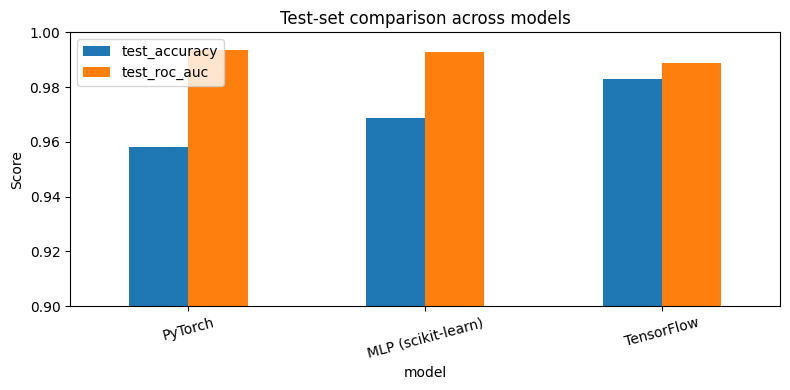

In [30]:
# ---------------------------------------------------------
# Save trained models + save metrics + compare all models
# ---------------------------------------------------------
import json
from pathlib import Path

artifacts_dir = Path("working") / "saved_models"
artifacts_dir.mkdir(parents=True, exist_ok=True)

comparison_rows = []

# 1) Scikit-learn MLP
if "model_ML" in globals():
    dump(model_ML, artifacts_dir / "mlp_model.joblib")
    comparison_rows.append(
        {
            "model": "MLP (scikit-learn)",
            "test_accuracy": float(test_acc_ML) if "test_acc_ML" in globals() else np.nan,
            "test_roc_auc": float(test_roc_auc_ML) if "test_roc_auc_ML" in globals() else np.nan,
        }
    )
    print("Saved:", artifacts_dir / "mlp_model.joblib")
else:
    print("MLP model not found in memory. Run MLP cells first.")

# 2) TensorFlow model
if "final_model_TF" in globals():
    final_model_TF.save(artifacts_dir / "tf_model.keras")
    comparison_rows.append(
        {
            "model": "TensorFlow",
            "test_accuracy": float(test_acc_TF) if "test_acc_TF" in globals() else np.nan,
            "test_roc_auc": float(test_auc_TF) if "test_auc_TF" in globals() else np.nan,
        }
    )
    print("Saved:", artifacts_dir / "tf_model.keras")
else:
    print("TensorFlow model not found in memory. Run TensorFlow cells first.")

# 3) PyTorch model
if (
    "final_model" in globals()
    and "nn" in globals()
    and isinstance(final_model, nn.Module)
):
    torch.save(final_model.state_dict(), artifacts_dir / "torch_model_state.pt")

    torch_meta = {
        "input_dim": int(X_common_train_s.shape[1]),
        "best_cfg": best_cfg if "best_cfg" in globals() else None,
    }
    with open(artifacts_dir / "torch_model_meta.json", "w", encoding="utf-8") as f:
        json.dump(torch_meta, f, indent=2)

    comparison_rows.append(
        {
            "model": "PyTorch",
            "test_accuracy": float(torch_test_acc) if "torch_test_acc" in globals() else np.nan,
            "test_roc_auc": float(torch_test_auc) if "torch_test_auc" in globals() else np.nan,
        }
    )
    print("Saved:", artifacts_dir / "torch_model_state.pt")
    print("Saved:", artifacts_dir / "torch_model_meta.json")
else:
    print("PyTorch model not found in memory. Run Torch cells first.")


# Save metrics table to disk
comparison_df = pd.DataFrame(comparison_rows)
if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("test_roc_auc", ascending=False).reset_index(drop=True)

comparison_df.to_csv(artifacts_dir / "model_comparison.csv", index=False)
with open(artifacts_dir / "model_comparison.json", "w", encoding="utf-8") as f:
    json.dump(comparison_rows, f, indent=2)

print("Saved:", artifacts_dir / "model_comparison.csv")
print("Saved:", artifacts_dir / "model_comparison.json")

print("\n=== Model Comparison (test set) ===")
print(comparison_df)

# Quick visual comparison
if not comparison_df.empty:
    ax = comparison_df.set_index("model")[["test_accuracy", "test_roc_auc"]].plot(
        kind="bar",
        figsize=(8, 4),
        rot=15,
    )
    ax.set_ylabel("Score")
    ax.set_ylim(0.90, 1.0)
    ax.set_title("Test-set comparison across models")
    plt.tight_layout()
    plt.show()